# Experiments simiulation

In [49]:
import pathlib
from typing import Callable, Optional
import jupedsim as jps
import pedpy
from matplotlib.patches import Circle
from shapely.geometry import Polygon
from jupedsim.internal.notebook_utils import read_sqlite_file
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import plotly.io as pio
from IPython.display import display
from string import ascii_uppercase
import sys
pio.renderers.default = "browser"

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() or (p / "setup.py").exists() or (p / "src").exists():
            return p
    return start

ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(ROOT))
%matplotlib inline
import environments.environment as pol
from src.evac_sim.core.risk_simulation_values import RiskSimulationValues
from src.evac_sim.core.simulation_config import SimulationConfig
from src.evac_sim.core.agent_group import AgentGroup
from src.evac_sim.core.environment_info import EnvironmentInfo
from src.evac_sim.viz.animation import animate
from src.evac_sim.routing.setting_paths import *
from src.evac_sim.envs.journey_configuration import set_journeys
from src.evac_sim.simulation.simulation_manager import set_agents_in_simulation, run_agent_simulation
from src.evac_sim.risk.risk_simulation import simulate_risk
from src.evac_sim.db.group_path_db_manager import create_group_path_table
from src.evac_sim.db.simulation_results_db_manager import write_experiment_metrics, write_experiment, create_tables, read_all_experiment_metrics, export_experiment_metrics_to_csv, export_experiments_to_csv
from src.evac_sim.db.danger_sim_db_manager import get_risks_grouped_by_frame, create_risk_table, get_risk_levels_by_frame
from src.evac_sim.db.agent_area_db_manager import *

try:
    %reload_ext autoreload
except:
    %load_ext autoreload
%autoreload 2

## Global Configuration

In [50]:
PROJECT_ROOT = Path().resolve().parents[0]
CONFIG_DIR = PROJECT_ROOT / "configs"
SQLITE_DIR  = PROJECT_ROOT / "data" / "sqlite"
IMAGES_DIR = PROJECT_ROOT / "results" / "images"
RESULTS_CSV_DIR = PROJECT_ROOT / "results" / "CSV"

def ensure_data_sqlite_dir(project_root: Path) -> Path:
    data_dir = project_root / "data"
    sqlite_dir = data_dir / "sqlite"

    sqlite_dir.mkdir(parents=True, exist_ok=True)

    return sqlite_dir

def load_simulation_config(case_id="representative_case", config_name="study.yaml"):
    config_file = CONFIG_DIR / config_name
    with open(config_file, "r") as f:
        all_configs = yaml.safe_load(f)
    return all_configs[case_id]

def select_environment(name):
    environments = {
        "cruise_ship": pol.get_cruise_ship,
        "cruise_ship_v2": pol.get_cruise_ship_v2,
        "mall": pol.get_mall,
        "theme_park": pol.get_theme_park,
        "simple_3x3": pol.get_simple_3x3,
        "comparing_algorithms": pol.get_comparing_algorithms_pol,
    }
    return environments[name]()

def init_db_connection(
    db_file: str,
    create_fn: Optional[Callable[[sqlite3.Connection, bool], None]] = None,
    force_reset: bool = False,
) -> sqlite3.Connection:
    """
    Opens a SQLite connection and initializes tables.

    Args:
        db_file: Path to the SQLite database file.
        create_fn: Function that creates tables. Must accept
                   (connection, force_reset).
        force_reset: If True, tables are dropped and recreated.

    Returns:
        sqlite3.Connection: Ready-to-use database connection.
    """
    conn = sqlite3.connect(db_file)

    if create_fn is not None:
        create_fn(conn, force_reset=force_reset)

    return conn

In [51]:
# -------------------------------
# Global Configuration
# -------------------------------

# Load config
config_name="study.yaml"
simulation_name = "representative_case_theme_park"
cfg = load_simulation_config(simulation_name, config_name)

# Load environment
Environment = select_environment(cfg["environment"])  # just change string here
pol.set_targets(cfg["targets"], Environment)

# Extract environment info
Environment_name = Environment.name
complete_area = Environment.complete_area
obstacles = Environment.obstacles
sources = cfg["sources"]
targets = cfg["targets"]
waypoints = Environment.waypoints
walkable_area = Environment.walkable_area
G = Environment.graph
specific_areas = Environment.specific_areas

# Mode configuration
mode_type = cfg.get("mode_type", 0)
mode_names = [
    "Low_awareness_efficient_paths",
    "High_awareness_efficient_paths",
    "Low_awareness_centrality_path",
    "High_awareness_centrality_path"
]
mode_indices = {
    0: [0, 1, 2, 3],
    1: [0, 1], # half effcient - half centrality
    2: [0, 1],
    3: [2, 3],
    4: [2]
}

if mode_type not in mode_indices:
    raise ValueError(f"Unsupported mode_type: {mode_type}")
modes = mode_indices[mode_type]
modes_names = [mode_names[i] for i in modes]

# General simulation config
total_agents = cfg["agents"]
risk_seed = cfg["risk_seed"]
risk_iterations = cfg["risk_iterations"]
risk_increase_chance = cfg["risk_increase_chance"]
risk_threshold = cfg["risk_threshold"]
gamma = cfg["gamma"]
stairs_max_speed = cfg["stairs_max_speed"]
normal_max_speed = cfg["normal_max_speed"]
starting_risks = [tuple(x) for x in cfg.get("starting_risks", []) or []]
risk_overrides = [tuple(x) for x in cfg.get("risk_overrides", []) or []]
risk_nodes_for_db = [(0, node, risk) for node, risk in starting_risks] + risk_overrides
use_random_risk_layout = True

# Group behavior
awareness_levels_per_group = [0, 1, 0, 1]
algorithm_per_group = [0, 0, 1, 1]

# Frame intervals
every_nth_frame_simulation = cfg["every_nth_frame_simulation"]
every_nth_frame_animation = cfg["every_nth_frame_animation"]

# Paths
ensure_data_sqlite_dir(PROJECT_ROOT)
connection_file = SQLITE_DIR  / (
    f"{Environment_name}_risks.db" if use_random_risk_layout
    else f"{Environment_name}_risks_node_8_5_p.db"
)
paths_file = SQLITE_DIR  / f"{Environment_name}_paths.db"
group_path_file = SQLITE_DIR  / f"{Environment_name}_group_paths_data.db"
results_db_path_file = SQLITE_DIR  / "results_simulation.db"
# results_db_path_file = SQLITE_DIR  / "results_simulation_exp.db"

# Connections
risk_db_conn = init_db_connection(connection_file, create_risk_table, False)
paths_conn = init_db_connection(paths_file, create_paths_table, False)
group_path_conn = init_db_connection(group_path_file, create_group_path_table, False)
results_db_conn = init_db_connection(results_db_path_file, create_tables, False)

# Empty structures for later use
trajectory_files = {}
agent_groups_per_mode = {}
agent_area_files = {}
simulation_seed = risk_seed if use_random_risk_layout else None


In [52]:
def algorithm_awareness_to_mode(algorithm: str, awareness: str) -> int:
    """
    Maps (algorithm, awareness) to a mode id:
        0 -> Efficient + Low
        1 -> Efficient + High
        2 -> Centrality + Low
        3 -> Centrality + High
    """
    alg = algorithm.strip().lower()
    aw = awareness.strip().lower()

    if alg == "efficient" and aw == "low":
        return 0
    if alg == "efficient" and aw == "high":
        return 1
    if alg == "centrality" and aw == "low":
        return 2
    if alg == "centrality" and aw == "high":
        return 3

    raise ValueError(f"Invalid algorithm/awareness combination: {algorithm}, {awareness}")


In [53]:
experiment_id = write_experiment(
    connection=results_db_conn,
    name=simulation_name,
    risk_nodes=risk_nodes_for_db,
    source_nodes=sources,
    agents_per_source=total_agents,
    random_seed=simulation_seed
)

## Environment

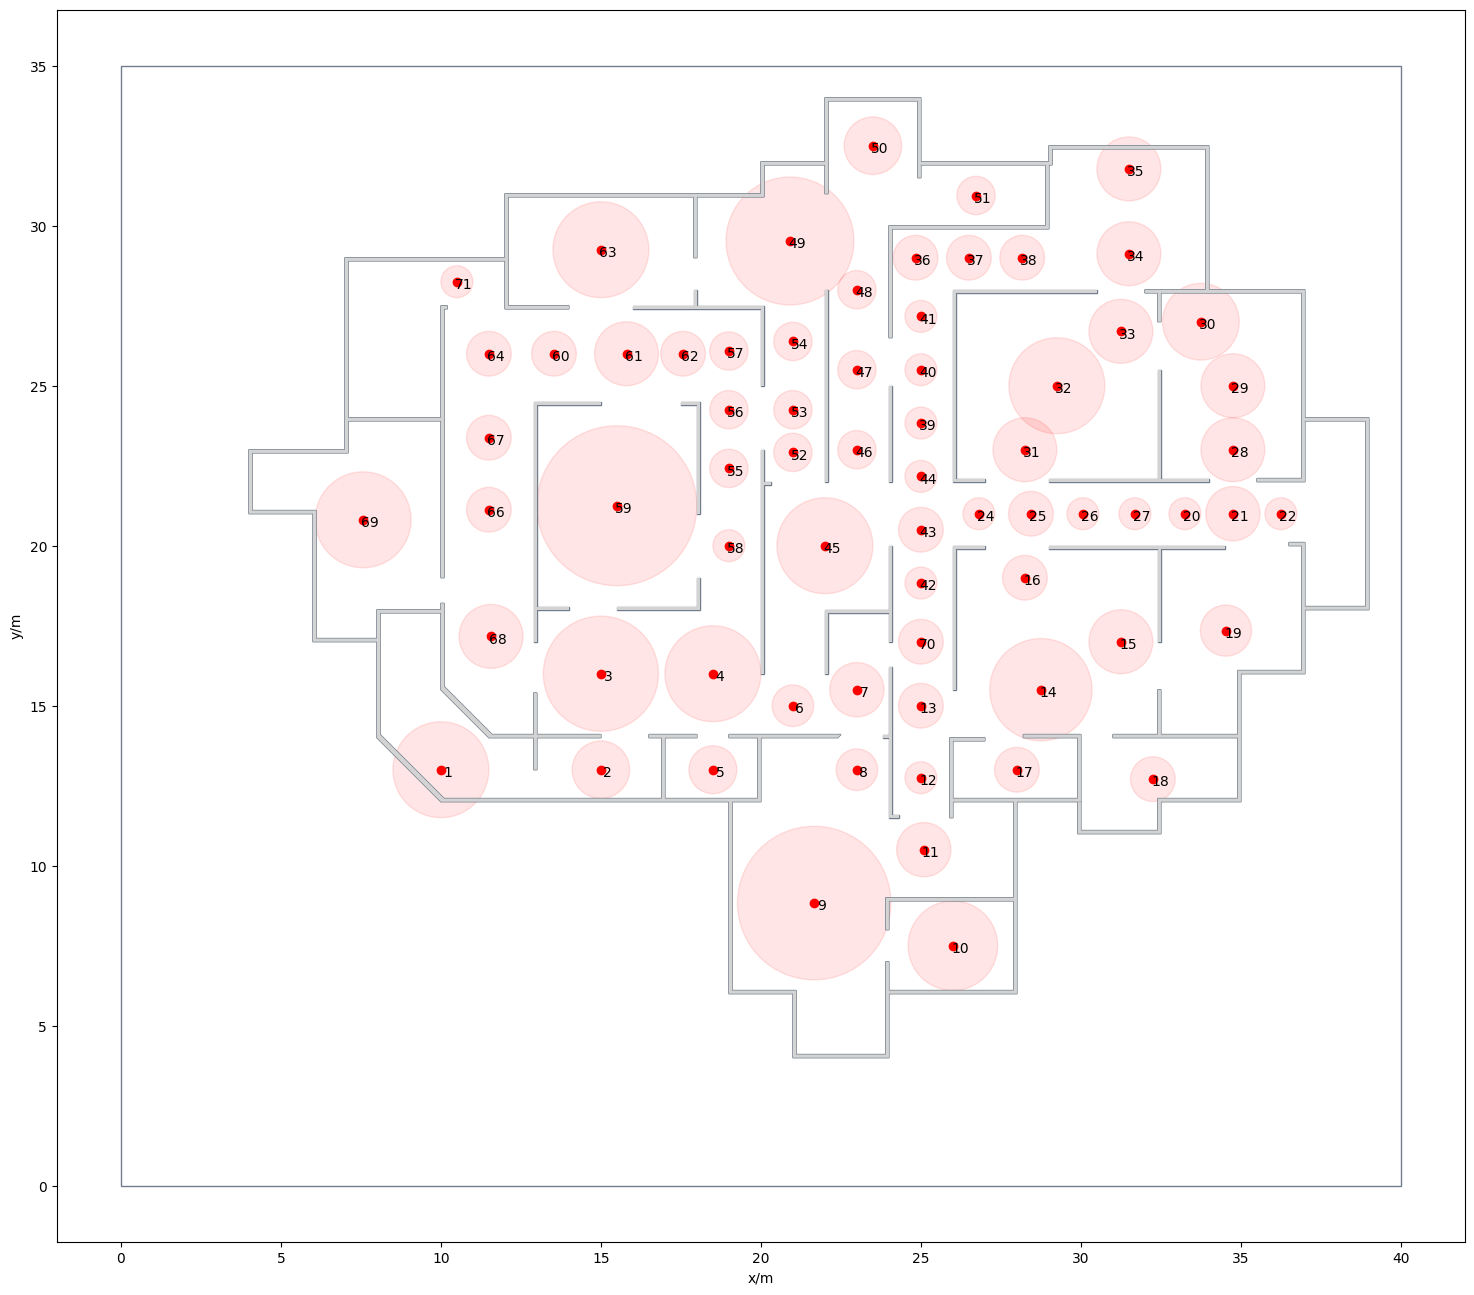

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(24, 16))
ax.set_aspect("equal")
pedpy.plot_walkable_area(walkable_area=walkable_area, axes=ax)

for idx, (waypoint, distance) in waypoints.items():
    ax.plot(waypoint[0], waypoint[1], "ro")
    ax.annotate(
        f"{idx}",
        (waypoint[0], waypoint[1]),
        textcoords="offset points",
        xytext=(5, -5),
        ha="center",
    )
    circle = Circle(
        (waypoint[0], waypoint[1]), distance, fc="red", ec="red", alpha=0.1
    )
    ax.add_patch(circle)


plt.savefig(IMAGES_DIR / 'cruise_ship_layout.png', dpi=300)

## Configuration of Simulation Scenarios

In [55]:
# Dictionary to store simulations for different percentages of agents
simulations = {}

# Loop over each percentage value to create a corresponding simulation
for mode in modes:
    # Define the output file path for storing the simulation trajectories
    trajectory_file = SQLITE_DIR / f"{Environment_name}_modes_{mode}.sqlite"

    # Create a new simulation instance using JPS (JuPedSim)
    simulation = jps.Simulation(
        model=jps.CollisionFreeSpeedModel(  # Define the agent movement model
            strength_neighbor_repulsion=2.6,  # Strength of repulsion between neighboring agents
            range_neighbor_repulsion=0.1,  # Distance at which agents start repelling each other
            range_geometry_repulsion=0.05,  # Distance at which agents start avoiding obstacles
        ),
        geometry=walkable_area.polygon,  # Define the walkable area for the simulation
        trajectory_writer=jps.SqliteTrajectoryWriter(  # Specify where to store simulation results
            output_file=pathlib.Path(trajectory_file),  # Save output to the specified SQLite file
            every_nth_frame=every_nth_frame_simulation

        ),

    )

    # Store the simulation object in the dictionary using the percentage as a key
    simulations[mode] = simulation

## Journey configuration

In [56]:
# In journey_configuration.py

## Allocate Agents

In [57]:
positions = dict()
for i, source in enumerate(sources):
    positions[source] = jps.distribute_by_number(
        polygon=specific_areas[source],
        number_of_agents=total_agents[i],
        distance_to_agents=0.4,
        distance_to_polygon=0.5, # 0.2 foe crowding case
        seed=45131502,
    )

## Launching the Simulation

In [58]:
# Simulation parameters
riskSimulationValues = RiskSimulationValues(risk_iterations, risk_increase_chance, risk_threshold, starting_risks, risk_overrides)
try:
    if use_random_risk_layout:
        # Create or reset the risk table if random risk layout is enabled
        create_risk_table(risk_db_conn)

        # Simulate risk propagation and store results in the database
        simulate_risk(riskSimulationValues, every_nth_frame_animation, G, targets, risk_db_conn, simulation_seed) # animation not every frame is shown in the animation
    # get first frame risk table
    risk_first_frame= get_risk_levels_by_frame(risk_db_conn, 0)
finally:
    # Ensure the database connection is closed after operations
    risk_db_conn.close()

In [59]:
create_group_path_table(group_path_conn)
EnvInf = EnvironmentInfo(G, paths_conn, floor_number=Environment.floor_number)
if Environment.floor_number > 1:
    EnvInf.floors = Environment.floors
    EnvInf.floor_connecting_nodes = Environment.floor_connecting_nodes


for mode, simulation in simulations.items():

    agent_area_files[mode] = SQLITE_DIR / f"agent_area_{Environment_name}_mode_{mode}.db"
    agent_area_conn = sqlite3.connect(agent_area_files[mode])

    create_agent_area_table(agent_area_conn)

    exit_ids = {}
    for area_id in targets:
        exit_ids[area_id] = simulation.add_exit_stage(specific_areas[area_id])

    # Initialize a dictionary to store waypoint IDs
    waypoints_ids = {}
    # Convert waypoints into simulation waypoints with associated distances
    for node, (waypoint, distance) in waypoints.items():
        waypoints_ids[node] = simulation.add_waypoint_stage(waypoint, distance)

    agent_groups = dict()
    for i, source in enumerate(sources):

        if mode_type == 1:
            agent_group_aux = AgentGroup(None, None, None, i, mode)
        else:
            agent_group_aux = AgentGroup(None, None, None, algorithm_per_group[mode], awareness_levels_per_group[mode]) # other cases

        path = compute_alternative_path(targets, agent_group_aux, EnvInf, source, risk_per_node=risk_first_frame, gamma=gamma)

        # Set up a journey for the simulation
        journeys_ids = set_journeys(
            simulation, source, [path], waypoints_ids, exit_ids
        )

        # Retrieve the best path for the first source and its associated journey ID
        journey_id, best_path_source = journeys_ids[source][0]
        next_node = best_path_source[1]  # Get the next node on the best path
        first_waypoint_id = waypoints_ids[next_node]  # Determine the waypoint ID for the next node

        agents = set_agents_in_simulation(simulation, positions[source], journey_id, first_waypoint_id, normal_max_speed)

        agent_group_aux.path = path

        # currently unnecessary
        agents_initial_nodes = {}
        for agent in agents:
            agents_initial_nodes[agent] = path[0]
        agent_group_aux.current_nodes = agents_initial_nodes

        agent_group_aux.agents = agents

        agent_groups[source] = agent_group_aux

    simulation_config = SimulationConfig(simulation, every_nth_frame_simulation, every_nth_frame_animation, waypoints_ids, exit_ids, gamma, normal_max_speed, stairs_max_speed)


    risk_db_conn = sqlite3.connect(connection_file)
    # Run the agent simulation, updating paths based on the risk levels
    run_agent_simulation(
        simulation_config,
        agent_groups,
        EnvInf,
        risk_db_conn,
        agent_area_conn,
        group_path_conn,
        threshold=risk_threshold,  # Threshold for avoiding high-risk areas
    )

    risk_db_conn.close()
    agent_area_conn.close()

    print(f"{mode} simulation finished")

    # Generate the trajectory file for the current percentage and store its path
    trajectory_file = SQLITE_DIR / f"{Environment_name}_modes_{mode}.sqlite"
    trajectory_files[mode] = trajectory_file
    agent_groups_per_mode[mode] = agent_groups

paths_conn.close()
group_path_conn.close()

0 simulation finished
1 simulation finished
2 simulation finished
3 simulation finished


In [60]:
with sqlite3.connect(connection_file) as connection:
    all_risks = get_risks_grouped_by_frame(connection)

## Visualizing Agent Pathways

In [61]:
agent_trajectories = {}
specific_areas = pol.remove_obstacles_from_areas(specific_areas, obstacles)
for mode in modes:
    trajectory_file = trajectory_files[mode]
    agent_trajectories[mode], walkable_area = read_sqlite_file(
        trajectory_file
    )
    animate(
        agent_trajectories[mode],
        walkable_area,
        title_note=f"Mode: {mode_names[mode]}",
        risk_per_frame=all_risks,
        specific_areas=specific_areas,
        every_nth_frame=every_nth_frame_animation
    ).show()


## Analysus if the results

In [62]:
def random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

if mode_type == 2:
    def get_color(_):
        return "red"
elif mode_type in (3, 4):
    def get_color(_):
        return "blue"
else:
    color_cache = {}
    predefined_colors = ["red", "blue"]

    def get_color(ig):
        if ig not in color_cache:
            if len(color_cache) < len(predefined_colors):
                # First: red, second: blue
                color_cache[ig] = predefined_colors[len(color_cache)]
            else:
                # Then random colors
                color_cache[ig] = random_color()
        return color_cache[ig]

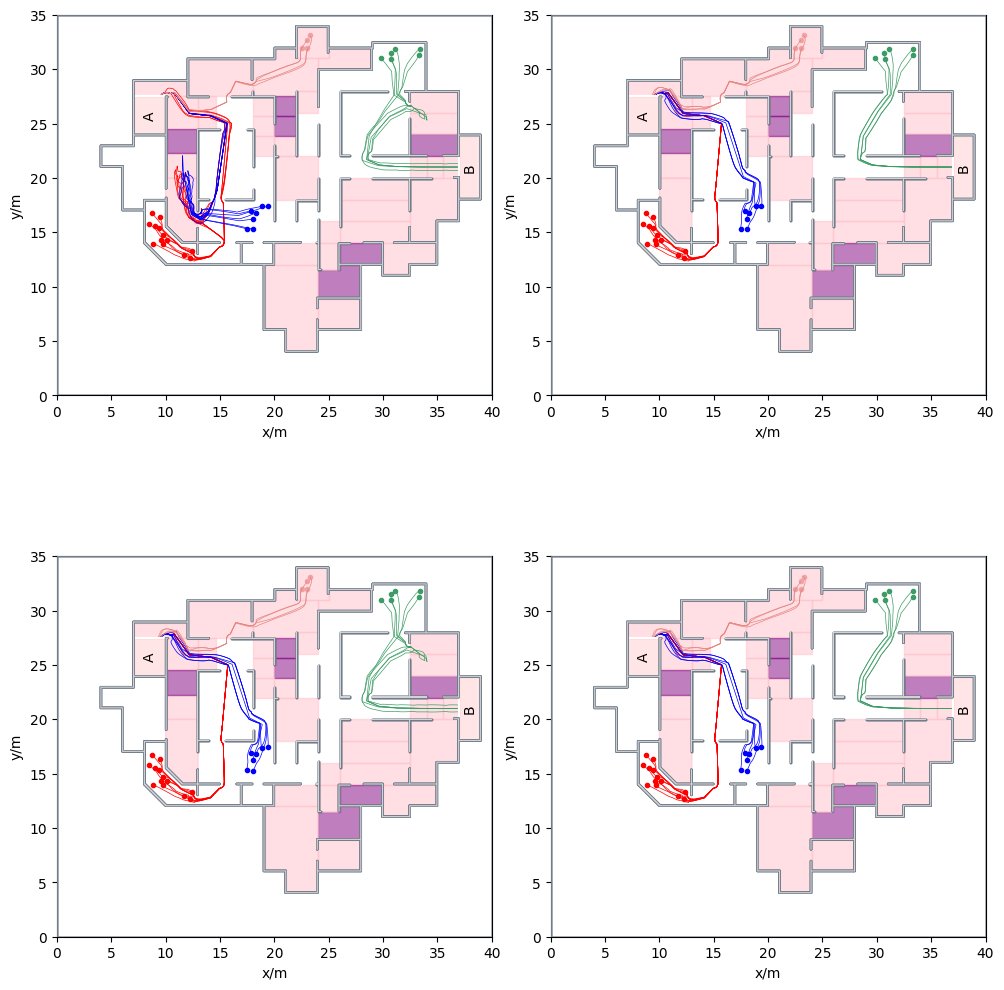

In [63]:
# show the hazzards of a specific frame
with sqlite3.connect(connection_file) as connection:
    # Fetch all risk data grouped by frame
    all_risks_frame_550 = get_risk_levels_by_frame(connection, 1500)

risky_areas = []
for area, risk in all_risks_frame_550.items():
    if risk > 0.0:
        risky_areas.append((area, risk))

# Retrieve the boundary coordinates of the complete_area polygon
minx, miny, maxx, maxy = complete_area.bounds

if mode_type == 0:
    nrows = 2
else:
    nrows = 1
# Create a figure with subplots arranged in two rows and two columns
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=2, figsize=(12, 16),
)

# Flatten the axes array to simplify iteration
axes = axes.flatten()

# Iterate over each subplot axis and its corresponding mode
for ax, mode in zip(axes, agent_groups_per_mode):
    # Extract trajectory data for the current mode
    trajectories = agent_trajectories[mode].data

    # Initialize a list to hold groups of agents for the current mode
    list_of_groups = []

    # Populate the list with agent groups from each source
    for source in sources:
        list_of_groups.append(agent_groups_per_mode[mode][source].agents)

    # Iterate over each group of agents
    for ig, group in enumerate(list_of_groups):
        # Create a TrajectoryData object for the current group
        traj = pedpy.TrajectoryData(
            trajectories[trajectories["id"].isin(group)],
            frame_rate=agent_trajectories[mode].frame_rate,
        )

        # Plot the trajectories of the current group on the current axis
        pedpy.plot_trajectories(
            traj=traj,
            walkable_area=walkable_area,
            axes=ax,
            traj_color=get_color(ig),
            traj_width=0.5,
            traj_start_marker=".",
        )

    # Set the title of the subplot to indicate the current mode
    # ax.set_title(f"Mode: {mode_names[mode]}")

    # Set the x and y axis limits based on the complete_area boundaries
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    # Ensure the aspect ratio is equal to maintain the scale of the plot
    ax.set_aspect('equal', adjustable='box')
    exit_letter_idx = 0
    # Overlay exit polygons on the plot
    for area_id in targets:
        pol = Polygon(specific_areas[area_id])
        # Extract the x and y coordinates of the polygon's exterior
        x, y = pol.exterior.xy

        # Fill the polygon area with a semi-transparent red color
        ax.fill(x, y, alpha=0.1, color="red")

        # Outline the polygon with a white border
        ax.plot(x, y, color="white")

        # Calculate the centroid of the polygon
        centroid = pol.centroid
        letter = ascii_uppercase[exit_letter_idx]
        # Place the name of the exit at the centroid position
        ax.text(
            centroid.x, centroid.y, letter, #area_id,
            ha="center", va="center", fontsize=10,
            rotation=90
        )
        exit_letter_idx += 1


    for area, risk_value in risky_areas:
        if risk_value > 0.0:
            x, y = specific_areas[area].exterior.xy
            if risk_value < risk_threshold:
                ax.fill(x, y, alpha=0.5, color="pink")
            else:
                ax.fill(x, y, alpha=0.5, color="purple")


# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Set the final size of the figure if needed
fig.set_size_inches((10, 12))

# Display the figure with all subplots
#plt.show()
plt.savefig(IMAGES_DIR / 'experiments', dpi=300)



Figure saved in C:\Users\aserr\Documents\GitHub\Evacuation_Simulation\results\images\experiment_risk_1300.png
Figure saved in C:\Users\aserr\Documents\GitHub\Evacuation_Simulation\results\images\experiment_risk_2400.png


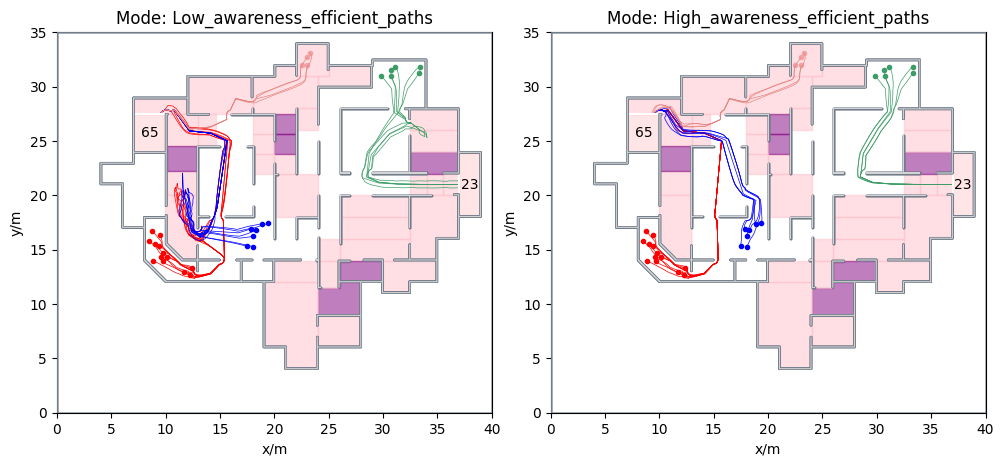

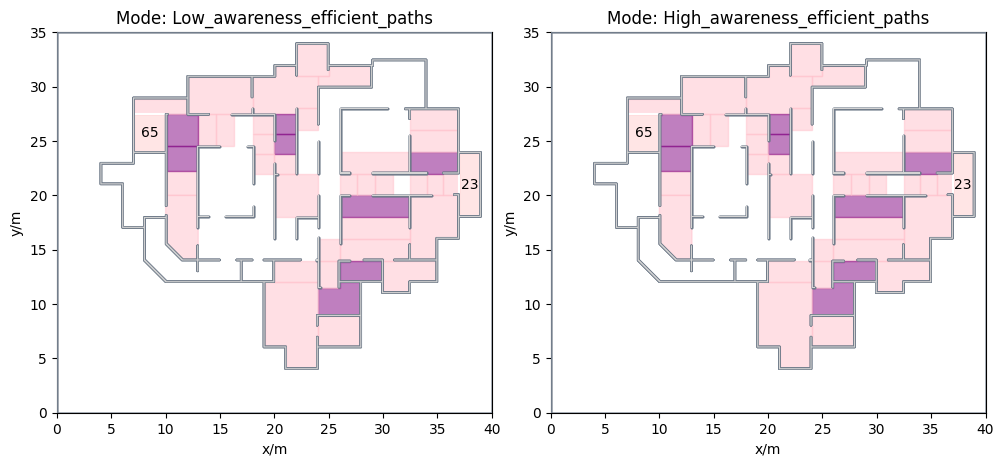

In [64]:
risk_frames = [1300, 2400]
trajectory_cuts = [(None, 2000), (2000, None)]
if mode_type==1:
    modes_names = ["High awareness", "Low awareness", "High awareness", "Low awareness"]
with sqlite3.connect(connection_file) as conn:
    for risk_frame, (f_start, f_end) in zip(risk_frames, trajectory_cuts):
        risks = get_risk_levels_by_frame(conn, risk_frame)
        risky_areas = [(area, r) for area, r in risks.items() if r > 0.0]

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
        axes = axes.flatten()

        for ax, mode in zip(axes, agent_trajectories.keys()):
            # DataFrame completo de este modo
            df_full = agent_trajectories[mode].data

            df = df_full
            if f_start is not None:
                df = df[df["frame"] >= f_start]
            if f_end is not None:
                df = df[df["frame"] <= f_end]

            for ig, source in enumerate(sources):
                color = get_color(ig)
                group_ids = agent_groups_per_mode[mode][source].agents
                df_group = df[df["id"].isin(group_ids)]
                traj_group = pedpy.TrajectoryData(df_group, frame_rate=agent_trajectories[mode].frame_rate)

                pedpy.plot_trajectories(
                    traj=traj_group,
                    walkable_area=walkable_area,
                    axes=ax,
                    traj_color=color,
                    traj_width=0.5,
                    traj_start_marker=".",
                )

            ax.set_title(f"Mode: {mode_names[mode]}")
            minx, miny, maxx, maxy = complete_area.bounds
            ax.set_xlim(minx, maxx)
            ax.set_ylim(miny, maxy)
            ax.set_aspect("equal", adjustable="box")

            # Dibujar salidas
            for area_id in targets:
                poly = specific_areas[area_id]
                x, y = poly.exterior.xy
                ax.fill(x, y, alpha=0.1, color="red")
                ax.plot(x, y, color="white")
                c = poly.centroid
                ax.text(c.x, c.y, area_id, ha="center", va="center", fontsize=10)

            # Colorear zonas de riesgo
            for area, rv in risky_areas:
                poly = specific_areas[area]
                x, y = poly.exterior.xy
                color = "purple" if rv >= risk_threshold else "pink"
                ax.fill(x, y, alpha=0.5, color=color)

        plt.tight_layout()
        fig.set_size_inches((10, 12))
        # 4) Guardar la figura
        out_path = IMAGES_DIR / f"experiment_risk_{risk_frame}.png"
        plt.savefig(out_path, dpi=600)
        print(f"Figure saved in {out_path}")

In [65]:
algorithm_map = {0: "Efficient", 1: "Centrality"}
awareness_map = {0: "Low", 1: "High"}

frame_rate = next(iter(agent_trajectories.values())).frame_rate

conn = sqlite3.connect(group_path_file)
df = pd.read_sql_query("SELECT * FROM group_path_data", conn)
conn.close()

df['next_path'] = df['next_path'].apply(json.loads)
df['path_length'] = df['next_path'].apply(len)

group_risk_stats = {}
group_meta_info = {}
avg_risk = {}
if mode_type != 1:
    for mode in modes:
        try:
            with sqlite3.connect(agent_area_files[mode]) as agent_area_connection:
                avg_risk[mode] = get_average_normalized_risk_exposure(agent_area_connection)
        except Exception as e:
            print(f"Error processing mode {mode}: {e}")

for (group_id, algorithm, awareness), group_df in df.groupby(['group_id', 'algorithm', 'awareness']):
    try:
        mean_remaining_path_risk     = group_df['est_risk_mean'].mean()
        remaining_path_risk_var = group_df['est_risk_var'].mean()
        avg_path_len  = group_df['path_length'].mean()

        key = f"{group_id}|{algorithm}|{awareness}"

        cumulative_risk = None
        if mode_type != 1:
            cumulative_risk = avg_risk[algorithm_awareness_to_mode(algorithm, awareness)]

        group_risk_stats[key] = {
            'mean_remaining_path_risk': mean_remaining_path_risk,
            'remaining_path_risk_var': remaining_path_risk_var,
            'avg_path_len': avg_path_len,
            'n_records': len(group_df),
            'cumulative_risk': cumulative_risk
        }

        group_meta_info[key] = {
            'group_id': group_id,
            'algorithm': algorithm,
            'awareness': awareness
        }

    except Exception as e:
        print(f"❌ Error processing group '{group_id}' (Alg: {algorithm}, Aw: {awareness}): {e}")

group_time_stats = {}
risk_exposure = {}

for mode, traj_obj in agent_trajectories.items():
    df = traj_obj.data
    fr = traj_obj.frame_rate

    conn_area = None
    if mode_type == 1:
        conn_area = sqlite3.connect(agent_area_files[mode])

    try:
        for source in sources:
            group = agent_groups_per_mode[mode][source]
            group_ids = group.agents
            group_id = source
            algorithm = algorithm_map[group.algorithm]
            awareness = awareness_map[group.awareness_level]
            key = f"{group_id}|{algorithm}|{awareness}"

            # Compute evacuation time per agent = max frame / frame rate
            per_agent_times = (
                df[df["id"].isin(group_ids)]
                .groupby("id")["frame"]
                .max()
                / fr
            )

            mean_time = per_agent_times.mean()
            max_time = per_agent_times.max()

            group_time_stats[key] = {
                'mean_time': mean_time,
                'max_time': max_time
            }

            if mode_type == 1:
                risk_exposure[key] = get_average_normalized_risk_exposure_by_group(conn_area, agent_ids=group_ids)
    finally:
        if conn_area is not None:
            conn_area.close()

records = []

for key in group_risk_stats:
    if key not in group_time_stats:
        print(f"⚠️ No time data found for group '{key}', skipping.")
        continue

    risk_info = group_risk_stats[key]
    time_info = group_time_stats[key]
    meta_info = group_meta_info[key]
    cumulative_risk_entry = risk_info['cumulative_risk']
    if cumulative_risk_entry == None:
        cumulative_risk_entry = risk_exposure[key]

    try:
        write_experiment_metrics(
            connection=results_db_conn,
            experiment_id=experiment_id,
            agent_group_id=meta_info['group_id'],
            algorithm=meta_info['algorithm'],
            awareness=meta_info['awareness'],
            n_records=risk_info['n_records'],
            mean_remaining_path_risk=risk_info['mean_remaining_path_risk'],
            remaining_path_risk_var=risk_info['remaining_path_risk_var'],
            avg_path_length=risk_info['avg_path_len'],
            avg_time=time_info['mean_time'],
            max_time=time_info['max_time'],
            cumulative_risk_exposure=cumulative_risk_entry
        )

        print(f"✅ Saved group '{key}'")

        records.append({
            'Group': meta_info['group_id'],
            'Algorithm': meta_info['algorithm'],
            'Awareness': meta_info['awareness'],
            'Avg Time (s)': round(time_info['mean_time'], 2),
            'Max Time (s)': round(time_info['max_time'], 2),
            'Path Length': round(risk_info['avg_path_len'], 2),
            'Mean Remaining Path Risk': round(risk_info['mean_remaining_path_risk'], 3),
            'Remaining Path Risk Var': round(risk_info['remaining_path_risk_var'], 3),
            "Cumulative Risk Exposure": round(cumulative_risk_entry, 3),
        })

    except Exception as e:
        print(f"❌ Error saving group '{key}': {e}")

df_summary = pd.DataFrame(records)
print("\n=== Final summary of stored metrics ===")
print(df_summary.to_string(index=False))


✅ Saved group '1|Centrality|High'
✅ Saved group '1|Centrality|Low'
✅ Saved group '1|Efficient|High'
✅ Saved group '1|Efficient|Low'
✅ Saved group '4|Centrality|High'
✅ Saved group '4|Centrality|Low'
✅ Saved group '4|Efficient|High'
✅ Saved group '4|Efficient|Low'
✅ Saved group '35|Centrality|High'
✅ Saved group '35|Centrality|Low'
✅ Saved group '35|Efficient|High'
✅ Saved group '35|Efficient|Low'
✅ Saved group '50|Centrality|High'
✅ Saved group '50|Centrality|Low'
✅ Saved group '50|Efficient|High'
✅ Saved group '50|Efficient|Low'

=== Final summary of stored metrics ===
 Group  Algorithm Awareness  Avg Time (s)  Max Time (s)  Path Length  Mean Remaining Path Risk  Remaining Path Risk Var  Cumulative Risk Exposure
     1 Centrality      High         30.06         37.74         3.81                     0.053                    0.007                     0.039
     1 Centrality       Low         30.06         37.74         3.81                     0.053                    0.007            

In [66]:
df_metrics = read_all_experiment_metrics(results_db_path_file)

# Convertir agent_group_id binario a entero
def convert_group_id(value):
    if isinstance(value, bytes):
        return int.from_bytes(value, byteorder='little')
    return value  # Already an int or compatible

df_metrics['agent_group_id'] = df_metrics['agent_group_id'].apply(convert_group_id)

# Display table
display(df_metrics[:])

Métricas cargadas correctamente.


,experiment_id,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,avg_time,max_time
0,2,73,Centrality,High,99,0.001198,0.000232,0.002052,19.090909,115.605000,119.07
1,2,73,Centrality,Low,102,0.002617,0.000673,0.007108,18.666667,115.815000,119.37
2,2,73,Efficient,High,99,0.000000,0.000000,0.001894,11.424242,79.000000,83.28
3,2,73,Efficient,Low,122,0.000000,0.000000,0.010656,9.459016,78.995000,83.25
4,2,77,Centrality,High,99,0.000000,0.000000,0.002052,14.373737,90.575000,99.75
5,2,77,Centrality,Low,102,0.000000,0.000000,0.007108,13.980392,89.600000,93.90
6,2,77,Efficient,High,99,0.000078,0.000007,0.001894,14.404040,89.910000,94.62
7,2,77,Efficient,Low,122,0.033344,0.012931,0.010656,25.172131,171.395000,174.90
8,2,82,Centrality,High,99,0.000000,0.000000,0.002052,26.868687,143.142000,148.32
9,2,82,Centrality,Low,102,0.007778,0.002478,0.007108,23.931373,135.120000,141.72


In [67]:
export_experiments_to_csv(results_db_path_file, RESULTS_CSV_DIR / "experiments.csv")
export_experiment_metrics_to_csv(results_db_path_file, RESULTS_CSV_DIR / "experiment_metrics.csv", include_experiment_context=True)


WindowsPath('C:/Users/aserr/Documents/GitHub/Evacuation_Simulation/results/CSV/experiment_metrics.csv')

In [68]:
def compute_density_from_dataframe(df, walkable_area, cell_size=0.5):
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()

    x_min, y_min, x_max, y_max = walkable_area.polygon.bounds

    x_bins = np.arange(x_min, x_max + cell_size, cell_size)
    y_bins = np.arange(y_min, y_max + cell_size, cell_size)

    heatmap, _, _ = np.histogram2d(x, y, bins=[x_bins, y_bins])
    return heatmap.T, x_bins, y_bins

def compute_unique_agents_per_cell(df, walkable_area, cell_size=0.5):
    x_min, y_min, x_max, y_max = walkable_area.polygon.bounds

    x_bins = np.arange(x_min, x_max + cell_size, cell_size)
    y_bins = np.arange(y_min, y_max + cell_size, cell_size)

    x = df["x"].to_numpy()
    y = df["y"].to_numpy()
    agent = df["id"].to_numpy()

    # Cell indices
    xi = np.digitize(x, x_bins) - 1
    yi = np.digitize(y, y_bins) - 1

    nx = len(x_bins) - 1
    ny = len(y_bins) - 1

    valid = (xi >= 0) & (xi < nx) & (yi >= 0) & (yi < ny)
    xi = xi[valid]
    yi = yi[valid]
    agent = agent[valid]

    # Flatten cell index, then unique by (cell, agent)
    cell = xi * ny + yi
    pairs = np.stack([cell, agent], axis=1)
    unique_pairs = np.unique(pairs, axis=0)

    # Count uniques per cell
    cell_ids, counts = np.unique(unique_pairs[:, 0], return_counts=True)
    heatmap = np.zeros(nx * ny, dtype=int)
    heatmap[cell_ids] = counts

    return heatmap.reshape(nx, ny).T, x_bins, y_bins


def plot_density_with_walkable_and_risks(
    heatmap, walkable_area,
    specific_areas, risky_areas,
    df, targets,
    title="Density Map",
    show_colorbars=True
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Polygon as MplPolygon
    from matplotlib.collections import PatchCollection
    from shapely.geometry import Polygon
    import numpy as np
    import matplotlib as mpl
    from matplotlib.colors import LinearSegmentedColormap
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    import shapely.geometry

    # ===== Figure and main axis
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    # ===== Map limits
    x_min, y_min, x_max, y_max = walkable_area.polygon.bounds
    extent = [x_min, x_max, y_min, y_max]

    # ===== Risk layer (background) — ORIGINAL COLORS
    norm_risk = mpl.colors.Normalize(vmin=0, vmax=1)
    risk_cmap = LinearSegmentedColormap.from_list(
        "pink_purple", ["pink", "purple"]
    )
    sm_risk = mpl.cm.ScalarMappable(cmap=risk_cmap, norm=norm_risk)
    sm_risk.set_array([])

    for area_id, risk_value in risky_areas:
        if area_id not in specific_areas:
            continue
        poly = Polygon(specific_areas[area_id])
        x, y = poly.exterior.xy
        ax.fill(
            x, y,
            color=risk_cmap(norm_risk(risk_value)),
            alpha=0.5,
            linewidth=0
        )

    # ===== Density layer (above risk) — ORIGINAL SETTINGS
    im_density = ax.imshow(
        heatmap,
        origin="lower",
        extent=extent,
        cmap="hot",
        interpolation="nearest",
        alpha=0.7
    )

    # ===== Walkable area outline
    patches = [MplPolygon(np.array(walkable_area.polygon.exterior.coords), closed=True)]
    for interior in walkable_area.polygon.interiors:
        patches.append(MplPolygon(np.array(interior.coords), closed=True))

    ax.add_collection(
        PatchCollection(
            patches,
            facecolor="none",
            edgecolor="black",
            linewidths=1
        )
    )

    # ===== Axes formatting
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(title)

    # ===== Colorbars (OPTIONAL, unchanged style)
    if show_colorbars:
        gap_img_to_bar = 0.208
        gap_between_bars = 0.235
        bar_width = "4.8%"
        bar_height = "100%"

        # Density colorbar
        ax_cb1 = inset_axes(
            ax,
            width=bar_width,
            height=bar_height,
            loc="lower left",
            bbox_to_anchor=(1.0 + gap_img_to_bar, 0.0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0
        )
        cbar1 = plt.colorbar(im_density, cax=ax_cb1, orientation="vertical")

        # Risk colorbar
        ax_cb2 = inset_axes(
            ax,
            width=bar_width,
            height=bar_height,
            loc="lower left",
            bbox_to_anchor=(1.0 + gap_img_to_bar + gap_between_bars, 0.0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0
        )
        cbar2 = plt.colorbar(sm_risk, cax=ax_cb2, orientation="vertical")

        # Remove ticks and frames (original behavior)
        for cax in (ax_cb1, ax_cb2):
            cax.tick_params(left=False, labelleft=False)
            for spine in cax.spines.values():
                spine.set_visible(False)

    # ===== Targets
    for area_id in targets:
        if area_id not in specific_areas:
            continue
        poly = Polygon(specific_areas[area_id])
        x, y = poly.exterior.xy
        ax.fill(x, y, color="orange", alpha=0.5, linewidth=0)
        c = poly.centroid
        ax.text(
            c.x, c.y,
            "target",
            color="white",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            zorder=10
        )

    # ===== Unique agents per area (frame 0)
    df_frame0 = df[df["frame"] == 0]

    for area_id, polygon_coords in specific_areas.items():
        poly = shapely.geometry.Polygon(polygon_coords)
        points_in_poly = df_frame0[df_frame0.apply(
            lambda row: poly.contains(
                shapely.geometry.Point(row["x"], row["y"])
            ),
            axis=1
        )]
        count = points_in_poly["id"].nunique()
        if count > 0:
            c = poly.centroid
            ax.text(
                c.x, c.y,
                str(count),
                color="white",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                zorder=10
            )

    plt.show()


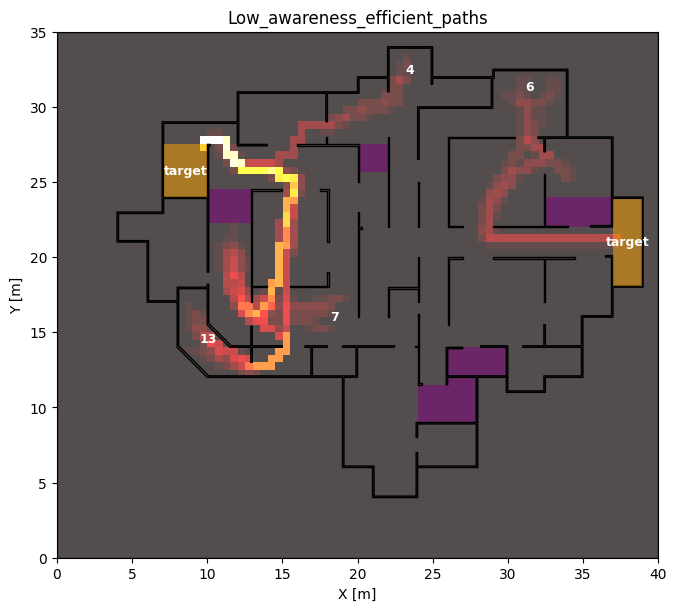

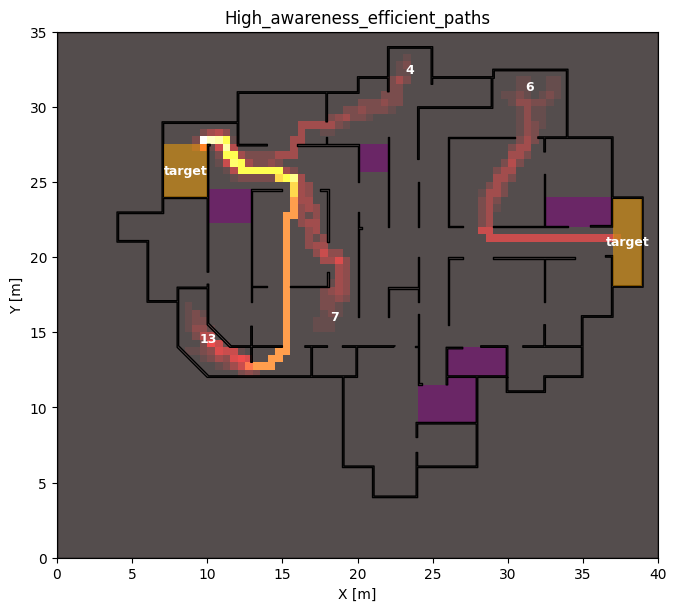

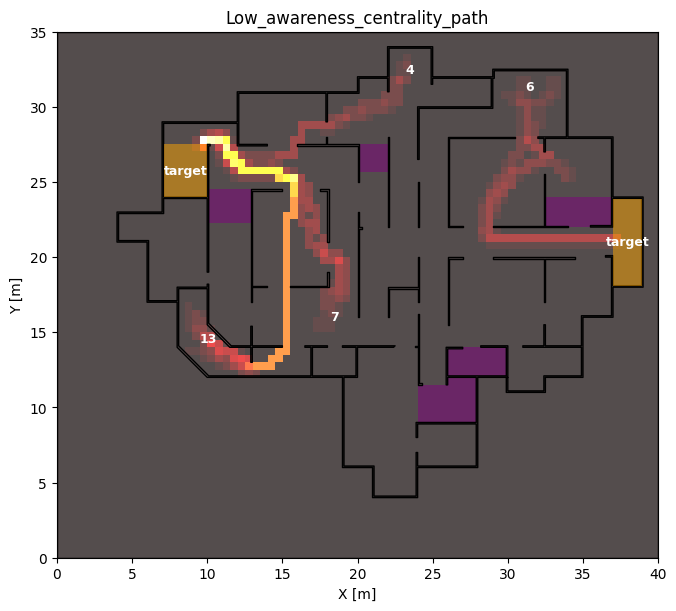

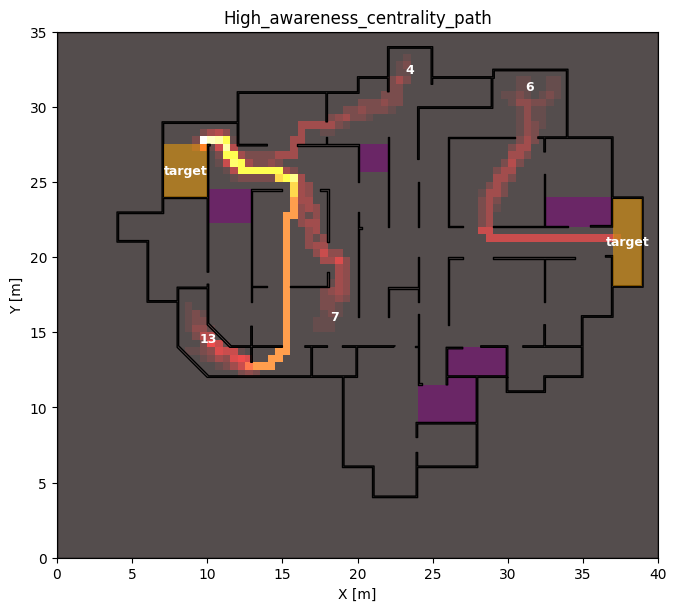

In [71]:
with sqlite3.connect(connection_file) as connection:
    # Fetch all risk data grouped by frame
    all_risks_frame = get_risk_levels_by_frame(connection,0)

risky_areas_den = []
for area, risk in all_risks_frame.items():
    if risk > 0.0:
        risky_areas_den.append((area, risk))

for mode in modes:
    df = agent_trajectories[mode].data
    heatmap, x_bins, y_bins = compute_unique_agents_per_cell(df, walkable_area, cell_size=0.5)

    plot_density_with_walkable_and_risks(
        heatmap=heatmap,
        walkable_area=walkable_area,
        specific_areas=specific_areas,
        risky_areas=risky_areas_den,
        df=df,
        targets=targets,
        title=f"{mode_names[mode]}", # unique agentes per cell
        show_colorbars=False,
    )



In [70]:
with sqlite3.connect(connection_file) as connection:
    # Fetch all risk data grouped by frame
    all_risks_frame = get_risk_levels_by_frame(connection, 000)

risky_areas_den = []
for area, risk in all_risks_frame.items():
    if risk > 0.0:
        risky_areas_den.append((area, risk))

for mode in modes:
    df = agent_trajectories[mode].data
    heatmap, x_bins, y_bins = compute_density_from_dataframe(df, walkable_area, cell_size=0.5)

    plot_density_with_walkable_and_risks(
        heatmap=heatmap,
        x_bins=x_bins,
        y_bins=y_bins,
        walkable_area=walkable_area,
        specific_areas=specific_areas,
        risky_areas=risky_areas_den,
        risk_threshold=0.5,
        df=df,
        targets=targets,
        title=f"{mode_names[mode]}" # Density + risk
    )


TypeError: plot_density_with_walkable_and_risks() got an unexpected keyword argument 'x_bins'

## Calculate profiles

## Evacuation Times vs Mode

In [ ]:
evac_times = []
for mode, traj in agent_trajectories.items():
    t_evac = traj.data["frame"].max() / traj.frame_rate # time equals frame / frame rate
    evac_times.append(t_evac)

for mode in modes:
    print(f"Mode: {modes_names[mode]}, time: {evac_times[mode]:2f}")

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(modes_names),
        y=evac_times,
        marker=dict(size=10),
        mode="lines+markers",
        name="Evacuation Times",
    )
)

fig.update_layout(
    title="Evacuation Times vs. Modes",
    xaxis_title="Mode",
    yaxis_title="Evacuation Time (s)",
)

fig.show()

## Average agent in group time

In [ ]:
# Define the plotting colors in the same order as 'sources'
colors = ["red", "blue", "green", "purple"]

# Collect average evacuation times per group and mode, including the color and max time
records = []
for mode, traj_obj in agent_trajectories.items():
    df = traj_obj.data
    fr = traj_obj.frame_rate
    for ig, source in enumerate(sources):
        group_ids = agent_groups_per_mode[mode][source].agents
        # Compute each agent's evacuation time = max frame / frame_rate
        per_agent_times = (
            df[df["id"].isin(group_ids)]
            .groupby("id")["frame"]
            .max()
            / fr
        )
        mean_time = per_agent_times.mean()
        max_time = per_agent_times.max()
        records.append({
            "Mode": modes_names[mode],
            "Source (Group)": source,
            "Color": colors[ig],
            "Average Evacuation Time (s)": mean_time,
            "Max Time (s)": max_time
        })

# Create DataFrame and print it
df_avg_times = pd.DataFrame(records)
print(df_avg_times.to_string(index=False))


## Risk vs Mode

In [ ]:
avg_risk = {}

for mode in modes:
    try:
        with sqlite3.connect(agent_area_files[mode]) as agent_area_connection:
            avg_risk[mode] = get_average_normalized_risk_exposure(agent_area_connection)
    except Exception as e:
        print(f"Error processing mode {mode}: {e}")


for mode in modes:
    print(f"Mode: {modes_names[mode]}, average risk: {avg_risk[mode]:.1f}")

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=list(modes_names),
        y=list(avg_risk.values()),
        name="Average Risks"
    )
)

fig.update_layout(
    title="Average Risks vs. Modes",
    xaxis_title="Mode",
    yaxis_title="Risks"
)

fig.show()

In [ ]:
risk_sum = {}

for mode in modes:
    try:
        with sqlite3.connect(agent_area_files[mode]) as agent_area_connection:
            risk_sum[mode] = calculate_average_agent_combined_risk(agent_area_connection)
    except Exception as e:
        print(f"Error processing mode {mode}: {e}")


for mode in modes:
    print(f"Mode: {modes_names[mode]}, total risk: {risk_sum[mode]:.1f}")

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=list(modes_names),
        y=list(risk_sum.values()),
        name="Total Risks"
    )
)

fig.update_layout(
    title="Total Risks vs. Modes",
    xaxis_title="Mode",
    yaxis_title="Risks"
)

fig.show()

In [ ]:
highest_risk = {}

for mode in modes:
    try:
        with sqlite3.connect(agent_area_files[mode]) as agent_area_connection:
            highest_risk[mode] = get_max_risk(agent_area_connection)
    except Exception as e:
        print(f"Error processing mode {mode}: {e}")


for mode in modes:
    print(f"Mode: {modes_names[mode]}, highest risk: {highest_risk[mode]:.1f}")

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=list(modes_names),
        y=list(highest_risk.values()),
        name="Highest Risks"
    )
)

fig.update_layout(
    title="Highest Risks vs. Modes",
    xaxis_title="Mode",
    yaxis_title="Risks"
)

fig.show()

In [ ]:
records = []

for mode in modes:
    # 1) Leer agent_area_data
    with sqlite3.connect(agent_area_files[mode]) as conn:
        df_aa = read_agent_area_data(conn)  # frame, agent_id, area, risk

    fr = agent_trajectories[mode].frame_rate

    # 2) Trajectory frames reales por agente
    traj_df = agent_trajectories[mode].data[['id', 'frame']]
    last_frames = traj_df.groupby('id')['frame'].max().to_dict()

    for source, group_obj in agent_groups_per_mode[mode].items():
        agents = group_obj.agents

        # 3) Construir timeline completo de cada agente
        full = traj_df[traj_df['id'].isin(agents)].copy()

        # 4) Mezclar con riesgo (puede haber NaN)
        full = full.merge(
            df_aa[['frame', 'agent_id', 'risk']],
            left_on=['id', 'frame'],
            right_on=['agent_id', 'frame'],
            how='left'
        ).drop(columns='agent_id')

        # 5) Rellenar el riesgo correctamente: backfill antes de ffill usando transform
        full.sort_values(['id', 'frame'], inplace=True)
        full['risk'] = (
            full
            .groupby('id')['risk']
            .transform(lambda s: s.bfill().ffill())
        )

        # 6) Detectar cambios de segmento de riesgo
        full['prev_risk'] = full.groupby('id')['risk'].shift()
        full['new_seg']   = (full['risk'] != full['prev_risk']).astype(int)
        full['seg_id']    = full.groupby('id')['new_seg'].cumsum()

        # 7) Último segmento por agente
        last_segs = full.groupby('id')['seg_id'].max().to_dict()

        # 8) Para cada segmento, calcular duración
        for (agent, seg), df_seg in full.groupby(['id', 'seg_id']):
            start = df_seg['frame'].iloc[0]

            if seg == last_segs[agent]:
                # último segmento: hasta el último frame real
                end = last_frames[agent]
            else:
                # no es último: inicio del siguiente segmento − 1
                next_start = full[
                    (full['id'] == agent) &
                    (full['seg_id'] == seg + 1)
                ]['frame'].iloc[0]
                end = next_start

            duration_s = (end - start) / fr

            records.append({
                'Mode':       modes_names[mode],
                'Group':      source,
                'Agent ID':   agent,
                'Risk Level': df_seg['risk'].iloc[0],
                'Time (s)':   duration_s
            })

# 9) Montar DataFrame de intervalos y sumar por agente y nivel de riesgo
df_intervals = pd.DataFrame(records)
df_totals = (
    df_intervals
    .groupby(['Mode','Group','Agent ID','Risk Level'], as_index=False)['Time (s)']
    .sum()
)
df_totals = df_totals[df_totals['Time (s)'] > 0].sort_values(['Agent ID','Risk Level'])
print("Time per Risk Level per Agent:")
print(df_totals.to_string(index=False))

# 10) Suma total de tiempo por agente
df_agent_sum = (
    df_totals
    .groupby(['Mode','Group','Agent ID'], as_index=False)['Time (s)']
    .sum()
    .rename(columns={'Time (s)': 'Total Time (s)'})
)
print("\nTotal Evacuation Time per Agent:")
print(df_agent_sum.to_string(index=False))

# 11) Estadística de tiempo máximo por modo
df_mode_stats = (
    df_agent_sum
    .groupby('Mode', as_index=False)['Total Time (s)']
    .max()
    .rename(columns={'Total Time (s)': 'Maximum_Time'})
)
print("\nMode Statistics (Min/Max):")
print(df_mode_stats.to_string(index=False))


In [ ]:
conn = sqlite3.connect(group_path_file)
df = pd.read_sql_query("SELECT * FROM group_path_data", conn)

df['next_path'] = df['next_path'].apply(json.loads)
df['path_length'] = df['next_path'].apply(len)

df_display = df[[
    'frame', 'group_id', 'algorithm', 'awareness',
    'current_area', 'path_length',
    'est_risk_mean', 'est_risk_max', 'est_risk_var',
    'risk_now'
]]

print("=== Group Path Data (primeras 20 filas) ===")
print(df_display.head(20).to_string(index=False))

summary = (
    df
    .groupby(['algorithm', 'awareness'])
    .agg(
        n_records=('frame', 'size'),
        mean_risk_mean=('est_risk_mean', 'mean'),
        max_risk_max=('est_risk_max', 'max'),
        mean_risk_var=('est_risk_var', 'mean'),
        avg_path_length=('path_length', 'mean')
    )
    .reset_index()
)

print("\n=== Resumen de estadísticas por algoritmo × awareness ===")
print(summary.to_string(index=False))

for (alg, aware), group_df in df.groupby(['algorithm', 'awareness']):
    plt.figure(figsize=(6,4))
    plt.plot(group_df['frame'], group_df['est_risk_mean'], marker='o')
    plt.title(f"Mean Estimated Risk over Time\n"
              f"Alg: {alg.capitalize()}  |  Awareness: {aware.capitalize()}")
    plt.xlabel("Frame")
    plt.ylabel("Mean Risk")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Step 1: Compute individual speeds and Voronoi cells for each mode

In [ ]:
individual_speed_per_mode = dict()
individual_voronoi_cells_per_mode = dict()

# Loop over each mode in the list of modes
for mode in modes:
    # Compute individual speed for the current mode
    individual_speed = pedpy.compute_individual_speed(
        traj_data=agent_trajectories[mode],
        frame_step=5,
        speed_calculation=pedpy.SpeedCalculation.BORDER_SINGLE_SIDED,
    )

    # Compute individual Voronoi polygons for the current mode
    individual_voronoi_cells = pedpy.compute_individual_voronoi_polygons(
        traj_data=agent_trajectories[mode],
        walkable_area=walkable_area,
        cut_off=pedpy.Cutoff(radius=0.8, quad_segments=3),
    )

    # Save the computed data into dictionaries keyed by mode
    individual_speed_per_mode[mode] = individual_speed
    individual_voronoi_cells_per_mode[mode] = individual_voronoi_cells

### Step 2: Compute density and speed profiles for each mode

In [ ]:


# list of (min_frame, max_frame) ranges
frame_ranges = [
    (0, 50),
    (300, 350),
    (600, 650),
    (900, 950),
    (1200, 1250),
    (1500, 1550),
]

# profiles_by_range[(minf, maxf)] = {
#   "density": {mode: density_profiles},
#   "speed":   {mode: speed_profiles}
# }
profiles_by_range = {}

for min_frame_profiles, max_frame_profiles in frame_ranges:
    density_profiles_per_mode = {}
    speed_profiles_per_mode = {}

    for mode in modes:
        voronoi_df = individual_voronoi_cells_per_mode[mode]
        speed_df = individual_speed_per_mode[mode]

        voronoi_filtered = voronoi_df[voronoi_df["frame"].between(min_frame_profiles, max_frame_profiles)]
        speed_filtered = speed_df[speed_df["frame"].between(min_frame_profiles, max_frame_profiles)]

        merged_data = pd.merge(
            voronoi_filtered,
            speed_filtered,
            on=["id", "frame"],
            how="inner",
        )

        density_profiles, speed_profiles = pedpy.compute_profiles(
            individual_voronoi_speed_data=merged_data,
            walkable_area=walkable_area.polygon,
            grid_size=0.5,
            speed_method=pedpy.SpeedMethod.ARITHMETIC,
        )

        density_profiles_per_mode[mode] = density_profiles
        speed_profiles_per_mode[mode] = speed_profiles

    profiles_by_range[(min_frame_profiles, max_frame_profiles)] = {
        "density": density_profiles_per_mode,
        "speed": speed_profiles_per_mode,
    }


### Step 3: Plot profiles with one row per mode and two columns per row
<div style="margin-left: 60px;"><h4>(first column: density, second column: speed)</h4></div>


In [ ]:
for (min_f, max_f), prof in profiles_by_range.items():
    speed_profiles_per_mode = prof["speed"]

    num_modes = len(modes)

    fig, axes = plt.subplots(
        nrows=num_modes,
        ncols=1,
        figsize=(12, 4 * num_modes),
        squeeze=False,  # siempre 2D
    )

    for idx, mode in enumerate(modes):
        ax_speed = axes[idx, 0]

        pedpy.plot_profiles(
            walkable_area=walkable_area,
            profiles=speed_profiles_per_mode[mode],
            axes=ax_speed,
            label="v / m/s",
            vmin=0,
            vmax=2,
            title=f"frames {min_f}-{max_f}",
        )

        # --- exits ---
        exit_letter_idx = 0

        for area_id in targets:
            if area_id not in specific_areas:
                continue

            poly = Polygon(specific_areas[area_id])
            x, y = poly.exterior.xy
            cx, cy = poly.centroid.x, poly.centroid.y

            # Zona exit (por encima del mapa, pero por debajo del texto)
            ax_speed.fill(
                x, y,
                color="#FF4500",
                alpha=0.5,
                linewidth=0,
                zorder=200,
            )

            letter = ascii_uppercase[exit_letter_idx]

            # Texto MUY por encima de todo
            ax_speed.text(
                cx, cy, letter,
                color="magenta",                 # <- negro
                fontsize=8,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=10000,                  # <- clave
                clip_on=False,                 # <- evita recortes raros
            )

            exit_letter_idx += 1

    # (opcional) fuerza a que el texto quede arriba del todo
    ax_speed.set_axisbelow(False)

    fig.tight_layout(pad=2)
    plt.show()


In [ ]:
for (min_f, max_f), prof in profiles_by_range.items():
    density_profiles_per_mode = prof["density"]
    speed_profiles_per_mode = prof["speed"]

    num_modes = len(modes)
    fig, axes = plt.subplots(nrows=num_modes, ncols=2, figsize=(12, 4 * num_modes))

    # Si num_modes == 1, axes no es matriz 2D; lo normalizamos
    if num_modes == 1:
        axes = [axes]

    for idx, mode in enumerate(modes):
        ax_density = axes[idx][0]
        ax_speed = axes[idx][1]

        pedpy.plot_profiles(
            walkable_area=walkable_area,
            profiles=density_profiles_per_mode[mode],
            axes=ax_density,
            label="$\\rho$ / 1/$m^2$",
            vmin=0,
            vmax=10,
            title=f"Density - {modes_names[0]} (frames {min_f}-{max_f})",
        )

        pedpy.plot_profiles(
            walkable_area=walkable_area,
            profiles=speed_profiles_per_mode[mode],
            axes=ax_speed,
            label="v / m/s",
            vmin=0,
            vmax=2,
            title=f"Speed - {modes_names[0]} (frames {min_f}-{max_f})",
        )

    fig.tight_layout(pad=2)
    plt.show()